In [3]:

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

In [5]:
import pandas as pd

df = pd.read_csv("spam.csv")
df.head(5)

,Class,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.groupby('Class').describe()


sms                                                               
      count unique                                                top freq
Class                                                                     
ham    4825   4516                             Sorry, I'll call later   30
spam    748    654  Please call our customer service representativ...    4

In [11]:
748/4825
#15% spam , 85% ham sms -> indicates class imbalance

0.15502590673575128

In [12]:

df_spam = df[df['Class']=='spam']
df_spam.shape

(748, 2)

In [13]:
df_ham = df[df['Class']=='ham']
df_ham.shape

(4825, 2)

In [14]:
df_ham_undersampled= df_ham.sample(df_spam.shape[0])
df_ham_undersampled.shape

(748, 2)

In [15]:

df_balanced = pd.concat([df_ham_undersampled, df_spam])
df_balanced.shape

(1496, 2)

In [16]:
df_balanced['Class'].value_counts()


Class
ham     748
spam    748
Name: count, dtype: int64

In [18]:
df_balanced['spam']=df_balanced['Class'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(5)

,Class,sms,spam
4965,spam,Dear Voucher holder Have your next meal on us....,1
3164,spam,This is the 2nd time we have tried to contact ...,1
3808,ham,Pls dont restrict her from eating anythin she ...,0
2149,ham,I will once i get home,0
717,spam,+449071512431 URGENT! This is the 2nd attempt ...,1


In [20]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced['sms'],df_balanced['spam'], stratify=df_balanced['spam'])

In [21]:
X_train.head(4)


2619    Hey pple...$700 or $900 for 5 nights...Excelle...
164     -PLS STOP bootydelious (32/F) is inviting you ...
4068    You are being contacted by our Dating Service ...
2207    URGENT! Your mobile No 07xxxxxxxxx won a £2,00...
Name: sms, dtype: object

In [22]:
#Now lets import BERT model and get embeding vectors for few sample statements
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [23]:
sentences= ["500$ discount. hurry up","Bhavin, are you up for a volleyball game tomorrow?"]


In [24]:
def get_sentence_embedding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']

In [26]:

e = get_sentence_embedding([
    "banana", 
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
]
)

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([e[0]],[e[1]])

array([[0.9911088]], dtype=float32)

In [28]:
cosine_similarity([e[0]],[e[3]])


array([[0.84703845]], dtype=float32)

In [29]:
cosine_similarity([e[3]],[e[4]])

array([[0.9872036]], dtype=float32)

In [30]:
#Bert layers
text_input = tf.keras.layers.Input(shape=(),dtype=tf.string, name='text')
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

# Neural network layers
l = tf.keras.layers.Dropout(0.1, name="dropout")(outputs['pooled_output'])
l = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(l)

# Use inputs and outputs to construct a final model
model = tf.keras.Model(inputs=[text_input], outputs = [l])


In [31]:
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text (InputLayer)              [(None,)]            0           []                               
                                                                                                  
 keras_layer (KerasLayer)       {'input_type_ids':   0           ['text[0][0]']                   
                                (None, 128),                                                      
                                 'input_mask': (Non                                               
                                e, 128),                                                          
                                 'input_word_ids':                                                
                                (None, 128)}                                                  

In [32]:
len(X_train)


1122

In [33]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [34]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
36/36 [==============================] - 447s 12s/step - loss: 0.6790 - accuracy: 0.6105 - precision: 0.6225 - recall: 0.5615
Epoch 2/10
36/36 [==============================] - 410s 11s/step - loss: 0.5375 - accuracy: 0.7879 - precision: 0.7733 - recall: 0.8146
Epoch 3/10
36/36 [==============================] - 374s 10s/step - loss: 0.4609 - accuracy: 0.8324 - precision: 0.8348 - recall: 0.8289
Epoch 4/10
36/36 [==============================] - 275s 8s/step - loss: 0.4096 - accuracy: 0.8708 - precision: 0.8574 - recall: 0.8895
Epoch 5/10
36/36 [==============================] - 313s 9s/step - loss: 0.3677 - accuracy: 0.8877 - precision: 0.8705 - recall: 0.9109
Epoch 6/10
36/36 [==============================] - 298s 8s/step - loss: 0.3487 - accuracy: 0.8832 - precision: 0.8548 - recall: 0.9234
Epoch 7/10
36/36 [==============================] - 373s 10s/step - loss: 0.3192 - accuracy: 0.9091 - precision: 0.8977 - recall: 0.9234
Epoch 8/10
36/36 [==========================

In [35]:
model.evaluate(X_test,  y_test)

12/12 [==============================] - 80s 6s/step - loss: 0.2726 - accuracy: 0.9225 - precision: 0.9341 - recall: 0.9091


[0.2725614607334137,
 0.9224599003791809,
 0.9340659379959106,
 0.9090909361839294]

In [36]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: [Errno 28] No space left on device
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: [Errno 28] No space left on device
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: [Errno 28] No space left on device
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
12/12 [==============================] - 84s 7s/step


In [37]:

import numpy as np

y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,

In [38]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_predicted)
cm

array([[175,  12],
       [ 17, 170]], dtype=int64)

Text(50.722222222222214, 0.5, 'Truth')

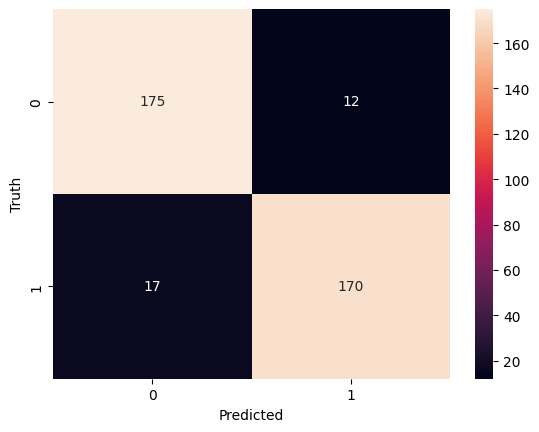

In [39]:

from matplotlib import pyplot as plt
import seaborn as sn
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [40]:
print(classification_report(y_test, y_predicted))


              precision    recall  f1-score   support

           0       0.91      0.94      0.92       187
           1       0.93      0.91      0.92       187

    accuracy                           0.92       374
   macro avg       0.92      0.92      0.92       374
weighted avg       0.92      0.92      0.92       374



In [41]:

reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

1/1 [==============================] - 2s 2s/step


array([[0.6626747 ],
       [0.7700416 ],
       [0.6847531 ],
       [0.15972525],
       [0.0958492 ]], dtype=float32)